# 🧠 Cours Complet : Chunking, Embedding & RAG
## Retrieval-Augmented Generation — de zéro à la mise en pratique

---

## 📚 Plan du cours

1. **Introduction au RAG** — Pourquoi ? Comment ?
2. **Le Dataset** — Préparation des données
3. **Le Chunking** — Découper les textes intelligemment
   - Fixed-size chunking
   - Sentence chunking
   - Recursive chunking
   - Semantic chunking
4. **Les Embeddings** — Transformer le texte en vecteurs
   - TF-IDF (classique)
   - Word2Vec (contextuel)
   - Sentence Transformers (état de l'art)
5. **Base de Données Vectorielle** — Stocker et rechercher
   - Implémentation from scratch
   - Avec FAISS
   - Avec ChromaDB
6. **Pipeline RAG Complet** — Tout assembler

---

## 🔧 Installation des dépendances

In [ ]:
# Installation de toutes les bibliothèques nécessaires
!pip install sentence-transformers faiss-cpu chromadb scikit-learn nltk matplotlib numpy pandas seaborn -q

# Téléchargement des ressources NLTK pour la tokenisation des phrases
import nltk
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')
print('✅ Installation terminée !')

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.0/52.0 kB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.8/23.8 MB 23.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.5/21.5 MB 19.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 278.2/278.2 kB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 44.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.1/17.1 MB 47.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.5/72.5 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 132.6/132.6 kB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.4/66.4 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 220.0/220.0 kB 11.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 105.4/105.4 kB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71.6/71.6 kB 1.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.6/60

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


✅ Installation terminée !


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


---
## 1. 🗂️ Introduction au RAG

### Qu'est-ce que le RAG ?

Le **RAG (Retrieval-Augmented Generation)** est une technique qui améliore les LLM (Large Language Models) en leur donnant accès à des connaissances externes.

```
┌─────────────────────────────────────────────────────────────┐
│                    Pipeline RAG                             │
│                                                             │
│  Documents ──► Chunking ──► Embedding ──► VectorDB          │
│                                               │             │
│  Question ──► Embedding ──► Recherche ────────┘             │
│                                  │                          │
│                               Contexte ──► LLM ──► Réponse  │
└─────────────────────────────────────────────────────────────┘
```

### Pourquoi le RAG ?
- Les LLM ont une **date de coupure** (pas de données récentes)
- Les LLM peuvent **halluciner** des faits
- Impossible de mettre **toute une base documentaire** dans le contexte
- Besoin de réponses **sourcées et vérifiables**

---
## 2. 📊 Préparation du Dataset

Nous allons créer un dataset réaliste sur **l'intelligence artificielle** avec différents types de documents.

In [ ]:
import pandas as pd
import numpy as np

# ============================================================
# DATASET : Corpus de documents sur l'Intelligence Artificielle
# Chaque document simule un article, une fiche ou un cours
# ============================================================

documents = [
    {
        "id": "doc_001",
        "titre": "Introduction au Machine Learning",
        "categorie": "fondamentaux",
        "texte": """
        Le machine learning (apprentissage automatique) est une branche de l'intelligence artificielle
        qui permet aux ordinateurs d'apprendre à partir de données sans être explicitement programmés.
        Il existe trois grands types d'apprentissage : supervisé, non supervisé et par renforcement.

        Dans l'apprentissage supervisé, le modèle apprend à partir d'exemples étiquetés.
        Par exemple, pour classer des emails en spam ou non-spam, on fournit au modèle des milliers
        d'emails déjà classifiés. Le modèle apprend alors les patterns qui distinguent les deux catégories.

        L'apprentissage non supervisé, lui, ne nécessite pas d'étiquettes.
        Le modèle découvre lui-même la structure cachée dans les données.
        Le clustering (regroupement) est un exemple classique : l'algorithme K-Means regroupe
        automatiquement les données similaires sans savoir à l'avance combien de groupes existent.

        L'apprentissage par renforcement est inspiré de la psychologie comportementale.
        Un agent apprend en interagissant avec un environnement, recevant des récompenses
        ou des pénalités selon ses actions. C'est cette technique qui a permis à AlphaGo
        de battre les meilleurs joueurs de Go au monde.
        """
    },
    {
        "id": "doc_002",
        "titre": "Les Réseaux de Neurones et le Deep Learning",
        "categorie": "deep_learning",
        "texte": """
        Les réseaux de neurones artificiels s'inspirent du fonctionnement du cerveau humain.
        Ils sont composés de couches de neurones artificiels connectés entre eux par des poids.
        Le deep learning (apprentissage profond) utilise des réseaux avec de nombreuses couches cachées.

        Un réseau de neurones basique comprend trois types de couches :
        La couche d'entrée reçoit les données brutes (pixels d'une image, mots d'une phrase).
        Les couches cachées transforment progressivement la représentation des données.
        La couche de sortie produit le résultat final (classe prédite, valeur numérique).

        La rétropropagation est l'algorithme clé de l'entraînement. Elle calcule le gradient
        de l'erreur par rapport à chaque poids du réseau, permettant de les ajuster
        pour minimiser l'erreur de prédiction. L'optimiseur Adam est aujourd'hui
        le plus utilisé car il adapte automatiquement le taux d'apprentissage.

        Les CNN (Convolutional Neural Networks) révolutionnent la vision par ordinateur.
        Ils utilisent des filtres de convolution pour détecter des features locales dans les images
        comme des bords, des textures, puis des formes de plus en plus complexes.

        Les RNN (Recurrent Neural Networks) et les LSTM (Long Short-Term Memory)
        sont conçus pour les données séquentielles comme le texte ou les séries temporelles.
        Ils maintiennent un état interne qui capture les dépendances à long terme.
        """
    },
    {
        "id": "doc_003",
        "titre": "L'Architecture Transformer et les LLM",
        "categorie": "nlp",
        "texte": """
        L'architecture Transformer, introduite en 2017 par l'article 'Attention Is All You Need',
        a révolutionné le traitement du langage naturel (NLP).
        Elle repose sur un mécanisme d'attention qui permet au modèle de pondérer
        l'importance de chaque mot dans une phrase par rapport aux autres.

        Le mécanisme d'attention multi-têtes (Multi-Head Attention) permet au modèle
        de capturer différents types de relations entre les mots simultanément.
        Certaines têtes capturent les relations syntaxiques, d'autres les relations sémantiques.

        BERT (Bidirectional Encoder Representations from Transformers) de Google
        est un modèle pré-entraîné sur de grandes quantités de texte.
        Il utilise un encodage bidirectionnel : il lit le texte dans les deux sens
        pour mieux comprendre le contexte de chaque mot.

        GPT (Generative Pre-trained Transformer) d'OpenAI est un modèle autorégressif
        qui prédit le prochain token à partir des tokens précédents.
        GPT-4 possède environ 1 trillion de paramètres et démontre des capacités
        de raisonnement et de génération de texte remarquables.

        Les Large Language Models (LLM) comme Claude, GPT-4, Llama ou Mistral
        sont entraînés sur des corpus massifs de texte et peuvent accomplir
        de nombreuses tâches : résumé, traduction, génération de code, questions-réponses.
        """
    },
    {
        "id": "doc_004",
        "titre": "Traitement du Langage Naturel (NLP)",
        "categorie": "nlp",
        "texte": """
        Le traitement du langage naturel (NLP) est le domaine de l'IA qui permet
        aux machines de comprendre et de générer du texte humain.
        Les principales tâches incluent la classification de texte, l'analyse de sentiment,
        la reconnaissance d'entités nommées (NER) et la traduction automatique.

        La tokenisation est la première étape : découper le texte en unités (tokens).
        Ces tokens peuvent être des mots, des sous-mots (BPE - Byte Pair Encoding)
        ou des caractères. GPT-4 utilise environ 100 000 tokens différents dans son vocabulaire.

        Le word embedding consiste à représenter chaque mot par un vecteur dense
        dans un espace de haute dimension. Word2Vec et GloVe sont les premières
        représentations vectorielles populaires. La propriété remarquable :
        vecteur(roi) - vecteur(homme) + vecteur(femme) ≈ vecteur(reine).

        L'analyse de sentiment détermine si un texte exprime une opinion positive,
        négative ou neutre. Elle est largement utilisée pour analyser les avis clients,
        les tweets ou les articles de presse financière.

        La reconnaissance d'entités nommées (NER) identifie et classifie
        les entités dans un texte : personnes, organisations, lieux, dates, etc.
        Par exemple, dans 'Emmanuel Macron est à Paris', NER identifie
        'Emmanuel Macron' comme une personne et 'Paris' comme un lieu.
        """
    },
    {
        "id": "doc_005",
        "titre": "Computer Vision et Traitement d'Images",
        "categorie": "vision",
        "texte": """
        La vision par ordinateur (Computer Vision) permet aux machines d'interpréter
        et de comprendre le monde visuel. Les applications sont nombreuses :
        détection d'objets, reconnaissance faciale, segmentation d'images,
        conduite autonome et diagnostic médical.

        La classification d'images consiste à attribuer une étiquette à une image entière.
        ResNet, VGG et EfficientNet sont des architectures CNN populaires pour cette tâche.
        ImageNet est le benchmark de référence avec 1000 catégories d'objets.

        La détection d'objets localise et identifie plusieurs objets dans une image.
        YOLO (You Only Look Once) est l'algorithme le plus rapide pour la détection en temps réel.
        Il découpe l'image en grille et prédit les boîtes englobantes et classes en une seule passe.

        La segmentation sémantique assigne une classe à chaque pixel de l'image.
        Elle est cruciale pour la conduite autonome où le véhicule doit distinguer
        la route, les piétons, les autres véhicules et les obstacles pixel par pixel.

        Les GANs (Generative Adversarial Networks) génèrent de nouvelles images réalistes.
        Un réseau générateur crée des images, un réseau discriminateur les évalue.
        Cette compétition produit des images de plus en plus réalistes.
        Les deepfakes sont un exemple controversé de cette technologie.
        """
    },
    {
        "id": "doc_006",
        "titre": "Éthique et Biais en Intelligence Artificielle",
        "categorie": "ethique",
        "texte": """
        L'éthique en IA est devenue un sujet majeur à mesure que les systèmes d'IA
        impactent des décisions importantes : embauche, justice, crédit bancaire, santé.
        Les principaux défis éthiques incluent les biais algorithmiques,
        la transparence, la vie privée et la responsabilité.

        Les biais algorithmiques surviennent quand les données d'entraînement
        reflètent des inégalités existantes. Un célèbre cas : le système COMPAS
        utilisé aux USA pour prédire la récidive criminelle discriminait
        les personnes afro-américaines. Le biais venait des données historiques d'arrestation.

        L'explicabilité (XAI - eXplainable AI) est cruciale pour les systèmes à enjeux élevés.
        LIME (Local Interpretable Model-agnostic Explanations) et SHAP
        sont des techniques qui expliquent pourquoi un modèle a pris une décision spécifique.

        La vie privée différentielle (Differential Privacy) permet d'entraîner
        des modèles sur des données sensibles tout en garantissant
        qu'aucune information individuelle ne peut être extraite.
        Apple et Google utilisent cette technique pour leurs modèles mobiles.

        Le règlement européen AI Act, adopté en 2024, classe les systèmes d'IA
        par niveau de risque et impose des obligations strictes pour les applications
        à haut risque comme la reconnaissance faciale ou les décisions d'embauche automatisées.
        """
    },
    {
        "id": "doc_007",
        "titre": "Reinforcement Learning et Agents Intelligents",
        "categorie": "fondamentaux",
        "texte": """
        L'apprentissage par renforcement (Reinforcement Learning, RL) est un paradigme
        où un agent apprend en interagissant avec un environnement.
        À chaque étape, l'agent observe l'état, choisit une action,
        reçoit une récompense et passe à un nouvel état.

        Le dilemme exploration-exploitation est central en RL.
        L'agent doit décider s'il exploite ce qu'il connaît déjà
        (pour maximiser les récompenses immédiates) ou explore de nouvelles actions
        (pour potentiellement découvrir de meilleures stratégies à long terme).

        Q-Learning est l'algorithme fondamental du RL. Il apprend une fonction Q(s,a)
        qui estime la valeur attendue de chaque action dans chaque état.
        DQN (Deep Q-Network) combine Q-Learning avec un réseau de neurones,
        permettant à l'agent de jouer à des jeux Atari au niveau humain.

        AlphaGo et AlphaZero de DeepMind représentent les succès les plus marquants du RL.
        AlphaZero a maîtrisé les échecs, le Go et le Shogi en quelques heures
        uniquement par auto-jeu, sans aucune connaissance humaine préalable.

        Le RLHF (Reinforcement Learning from Human Feedback) est utilisé
        pour aligner les LLM sur les préférences humaines.
        Un modèle de récompense est entraîné sur des préférences humaines,
        puis utilisé pour fine-tuner le LLM via RL. C'est la technique clé derrière ChatGPT.
        """
    },
    {
        "id": "doc_008",
        "titre": "MLOps et Déploiement de Modèles en Production",
        "categorie": "production",
        "texte": """
        Le MLOps (Machine Learning Operations) est l'ensemble des pratiques
        pour déployer et maintenir des modèles de ML en production de manière
        fiable et efficace. Il combine les principes du DevOps avec les spécificités du ML.

        Le cycle de vie d'un modèle ML comprend : collecte et préparation des données,
        entraînement et évaluation, packaging et déploiement, monitoring et maintenance.
        MLflow et Weights & Biases permettent de tracker les expériences et versions de modèles.

        Le model drift est un phénomène où la performance d'un modèle se dégrade
        car la distribution des données en production change par rapport aux données d'entraînement.
        Le concept drift se produit quand la relation entre les features et la cible change.

        Les conteneurs Docker et Kubernetes sont essentiels pour le déploiement scalable.
        Un modèle est packagé dans un conteneur avec toutes ses dépendances,
        puis orchestré par Kubernetes pour gérer la montée en charge automatique.

        Les plateformes cloud (AWS SageMaker, Google Vertex AI, Azure ML)
        offrent des services managés pour entraîner, déployer et monitorer des modèles ML
        sans gérer l'infrastructure sous-jacente.
        """
    }
]

# Conversion en DataFrame pour faciliter la manipulation
df = pd.DataFrame(documents)

# Nettoyage : suppression des espaces en début/fin de texte
df['texte'] = df['texte'].str.strip()

# Calcul de statistiques basiques
df['nb_mots'] = df['texte'].apply(lambda x: len(x.split()))
df['nb_caracteres'] = df['texte'].apply(len)

print(f'📚 Dataset créé : {len(df)} documents')
print(f'📊 Statistiques :')
print(df[['titre', 'categorie', 'nb_mots', 'nb_caracteres']].to_string(index=False))

📚 Dataset créé : 8 documents
📊 Statistiques :
                                        titre     categorie  nb_mots  nb_caracteres
             Introduction au Machine Learning  fondamentaux      161           1297
  Les Réseaux de Neurones et le Deep Learning deep_learning      199           1539
        L'Architecture Transformer et les LLM           nlp      182           1456
          Traitement du Langage Naturel (NLP)           nlp      190           1458
       Computer Vision et Traitement d'Images        vision      185           1439
Éthique et Biais en Intelligence Artificielle       ethique      181           1483
Reinforcement Learning et Agents Intelligents  fondamentaux      190           1467
MLOps et Déploiement de Modèles en Production    production      172           1294


---
## 3. ✂️ Le Chunking

### Pourquoi découper les documents ?

Les modèles d'embedding ont une **fenêtre de contexte limitée** (souvent 512 tokens).
De plus, des chunks plus petits permettent une **recherche plus précise**.

Il existe plusieurs stratégies de chunking, chacune avec ses avantages et inconvénients.

```
┌────────────────────────────────────────────────────────────────────┐
│  Document original                                                  │
│  ████████████████████████████████████████████████████████████████  │
│                                                                     │
│  Fixed-size chunking                                                │
│  ████████████ | ████████████ | ████████████ | ████████████          │
│  (coupures brutales, peut couper au milieu d'une idée)             │
│                                                                     │
│  Sentence chunking                                                  │
│  ██████. | ███████████. | ██████. | █████████████.                  │
│  (respecte les phrases, mais inégal en taille)                     │
│                                                                     │
│  Recursive chunking (avec overlap)                                  │
│  ██████████████ | ████|██████████████ | ████|████████               │
│  (overlap = chevauchement pour ne pas perdre le contexte)          │
└────────────────────────────────────────────────────────────────────┘
```

### 3.1 Fixed-Size Chunking (découpage à taille fixe)

In [ ]:
# ============================================================
# MÉTHODE 1 : Fixed-Size Chunking
# Principe : diviser le texte en morceaux de N caractères
# ✅ Avantages : simple, rapide, chunks de taille uniforme
# ❌ Inconvénients : peut couper au milieu d'un mot ou d'une idée
# ============================================================

def fixed_size_chunking(texte, taille_chunk=200, overlap=50):
    """
    Découpe un texte en chunks de taille fixe avec chevauchement.

    Paramètres:
    - texte      : le texte à découper
    - taille_chunk : nombre de caractères par chunk
    - overlap    : nombre de caractères partagés entre chunks consécutifs
                   (évite de perdre le contexte aux frontières)

    Retourne:
    - liste de dictionnaires avec le texte et les métadonnées du chunk
    """
    chunks = []

    # Position de départ dans le texte
    debut = 0

    while debut < len(texte):
        # Calculer la fin du chunk
        fin = debut + taille_chunk

        # Extraire le morceau de texte
        chunk_texte = texte[debut:fin]

        # Stocker le chunk avec ses métadonnées
        chunks.append({
            'texte': chunk_texte.strip(),       # Texte du chunk
            'debut': debut,                       # Position de départ
            'fin': min(fin, len(texte)),           # Position de fin
            'nb_caracteres': len(chunk_texte)     # Longueur
        })

        # Avancer la position de départ en tenant compte de l'overlap
        # Sans overlap : debut = fin
        # Avec overlap  : on recule de 'overlap' pour que les chunks se chevauchent
        debut = fin - overlap

    return chunks


# Test sur le premier document
texte_test = df.iloc[0]['texte']
chunks_fixed = fixed_size_chunking(texte_test, taille_chunk=300, overlap=50)

print(f'📄 Document original : {len(texte_test)} caractères')
print(f'✂️  Nombre de chunks (fixed-size) : {len(chunks_fixed)}')
print(f'\n--- EXEMPLES DE CHUNKS ---')

for i, chunk in enumerate(chunks_fixed[:3]):
    print(f'\n🔹 Chunk {i+1} [{chunk["debut"]}:{chunk["fin"]}]')
    print(f'   {repr(chunk["texte"][:100])}...')

📄 Document original : 1297 caractères
✂️  Nombre de chunks (fixed-size) : 6

--- EXEMPLES DE CHUNKS ---

🔹 Chunk 1 [0:300]
   "Le machine learning (apprentissage automatique) est une branche de l'intelligence artificielle \n    "...

🔹 Chunk 2 [250:550]
   "ge : supervisé, non supervisé et par renforcement.\n        \n        Dans l'apprentissage supervisé, "...

🔹 Chunk 3 [500:800]
   "d'emails déjà classifiés. Le modèle apprend alors les patterns qui distinguent les deux catégories.\n"...


### 3.2 Sentence Chunking (découpage par phrases)

In [ ]:
# ============================================================
# MÉTHODE 2 : Sentence Chunking
# Principe : regrouper N phrases consécutives dans un chunk
# ✅ Avantages : respecte la structure naturelle du langage
# ✅ Chaque chunk est sémantiquement cohérent (phrases complètes)
# ❌ Inconvénients : chunks de tailles très variables
# ============================================================

from nltk.tokenize import sent_tokenize

def sentence_chunking(texte, phrases_par_chunk=3, overlap_phrases=1):
    """
    Découpe un texte en groupes de phrases.

    Paramètres:
    - texte              : texte à découper
    - phrases_par_chunk  : nombre de phrases par chunk
    - overlap_phrases    : nombre de phrases partagées entre chunks

    Retourne:
    - liste de chunks avec leurs métadonnées
    """
    # Étape 1 : Tokeniser le texte en phrases avec NLTK
    # sent_tokenize reconnaît les fins de phrases (., !, ?)
    phrases = sent_tokenize(texte, language='french')

    # Supprimer les phrases trop courtes (artefacts de tokenisation)
    phrases = [p.strip() for p in phrases if len(p.strip()) > 20]

    chunks = []

    # Étape 2 : Regrouper les phrases par groupes
    i = 0
    while i < len(phrases):
        # Prendre 'phrases_par_chunk' phrases consécutives
        groupe = phrases[i : i + phrases_par_chunk]

        # Assembler les phrases en un seul texte
        chunk_texte = ' '.join(groupe)

        chunks.append({
            'texte': chunk_texte,
            'phrases': groupe,             # Garder les phrases individuelles
            'nb_phrases': len(groupe),     # Nombre de phrases dans ce chunk
            'nb_mots': len(chunk_texte.split()),  # Nombre de mots
            'index_debut': i               # Index de la 1ère phrase
        })

        # Avancer en tenant compte de l'overlap (chevauchement de phrases)
        i += (phrases_par_chunk - overlap_phrases)

    return chunks


# Test sur le premier document
chunks_sentences = sentence_chunking(texte_test, phrases_par_chunk=3, overlap_phrases=1)

print(f'📄 Document original : {len(texte_test.split())} mots')
print(f'✂️  Nombre de chunks (sentence) : {len(chunks_sentences)}')
print(f'\n--- EXEMPLES DE CHUNKS ---')

for i, chunk in enumerate(chunks_sentences[:3]):
    print(f'\n🔹 Chunk {i+1} ({chunk["nb_phrases"]} phrases, {chunk["nb_mots"]} mots)')
    print(f'   {chunk["texte"][:150]}...')

📄 Document original : 161 mots
✂️  Nombre de chunks (sentence) : 6

--- EXEMPLES DE CHUNKS ---

🔹 Chunk 1 (3 phrases, 47 mots)
   Le machine learning (apprentissage automatique) est une branche de l'intelligence artificielle 
        qui permet aux ordinateurs d'apprendre à parti...

🔹 Chunk 2 (3 phrases, 40 mots)
   Dans l'apprentissage supervisé, le modèle apprend à partir d'exemples étiquetés. Par exemple, pour classer des emails en spam ou non-spam, on fournit ...

🔹 Chunk 3 (3 phrases, 29 mots)
   Le modèle apprend alors les patterns qui distinguent les deux catégories. L'apprentissage non supervisé, lui, ne nécessite pas d'étiquettes. Le modèle...


### 3.3 Recursive Chunking (découpage récursif)

In [ ]:
# ============================================================
# MÉTHODE 3 : Recursive Character Text Splitting
# Principe : diviser en utilisant une hiérarchie de séparateurs
# Séparateurs essayés dans l'ordre : \n\n → \n → . → ' '
# ✅ Avantages : préserve la structure (paragraphes > phrases > mots)
# ✅ C'est l'approche de LangChain (RecursiveCharacterTextSplitter)
# ❌ Inconvénients : légèrement plus complexe à implémenter
# ============================================================

def recursive_chunking(texte, taille_max=300, overlap=50, separateurs=None):
    """
    Découpe récursivement en respectant la structure naturelle du texte.

    Algorithme :
    1. Essayer de diviser avec le premier séparateur (double saut de ligne)
    2. Si un morceau est encore trop grand, le re-diviser avec le séparateur suivant
    3. Continuer jusqu'à ce que tous les morceaux soient sous taille_max
    """
    # Hiérarchie des séparateurs (du plus structurant au moins structurant)
    if separateurs is None:
        separateurs = ['\n\n', '\n', '. ', ' ', '']

    def _split_recursif(texte, separateurs):
        """Fonction récursive interne."""

        # Cas de base : le texte est déjà assez court
        if len(texte) <= taille_max:
            return [texte.strip()] if texte.strip() else []

        # Cas de base : plus de séparateurs disponibles
        if not separateurs:
            # Forcer la découpe à taille_max
            return [texte[i:i+taille_max] for i in range(0, len(texte), taille_max - overlap)]

        # Essayer le séparateur courant
        separateur_courant = separateurs[0]
        prochains_separateurs = separateurs[1:]

        # Diviser avec ce séparateur
        morceaux = texte.split(separateur_courant)

        chunks_finaux = []
        buffer = ""  # Accumulateur pour fusionner des petits morceaux

        for morceau in morceaux:
            morceau = morceau.strip()
            if not morceau:
                continue

            if len(buffer) + len(morceau) <= taille_max:
                # Le morceau rentre dans le buffer → fusionner
                buffer = buffer + (separateur_courant if buffer else '') + morceau
            else:
                # Le buffer est plein → sauvegarder et commencer un nouveau buffer
                if buffer:
                    chunks_finaux.append(buffer.strip())

                if len(morceau) > taille_max:
                    # Ce morceau est trop grand → récursion avec le séparateur suivant
                    sous_chunks = _split_recursif(morceau, prochains_separateurs)
                    chunks_finaux.extend(sous_chunks)
                    buffer = ""
                else:
                    buffer = morceau

        # Ne pas oublier le dernier buffer
        if buffer:
            chunks_finaux.append(buffer.strip())

        return [c for c in chunks_finaux if c]

    # Lancer la récursion
    textes_chunks = _split_recursif(texte, separateurs)

    # Formater la sortie
    return [
        {
            'texte': chunk,
            'nb_caracteres': len(chunk),
            'nb_mots': len(chunk.split())
        }
        for chunk in textes_chunks
    ]


# Test sur le premier document
chunks_recursive = recursive_chunking(texte_test, taille_max=350, overlap=50)

print(f'📄 Document original : {len(texte_test)} caractères')
print(f'✂️  Nombre de chunks (recursive) : {len(chunks_recursive)}')

for i, chunk in enumerate(chunks_recursive):
    print(f'\n🔹 Chunk {i+1} ({chunk["nb_mots"]} mots, {chunk["nb_caracteres"]} chars)')
    print(f'   {chunk["texte"][:120]}...')

📄 Document original : 1297 caractères
✂️  Nombre de chunks (recursive) : 4

🔹 Chunk 1 (37 mots, 282 chars)
   Le machine learning (apprentissage automatique) est une branche de l'intelligence artificielle
qui permet aux ordinateur...

🔹 Chunk 2 (48 mots, 339 chars)
   Dans l'apprentissage supervisé, le modèle apprend à partir d'exemples étiquetés.
Par exemple, pour classer des emails en...

🔹 Chunk 3 (42 mots, 322 chars)
   Le modèle découvre lui-même la structure cachée dans les données.
Le clustering (regroupement) est un exemple classique ...

🔹 Chunk 4 (34 mots, 210 chars)
   Un agent apprend en interagissant avec un environnement, recevant des récompenses
ou des pénalités selon ses actions. C'...


### 3.4 Comparaison des méthodes de Chunking

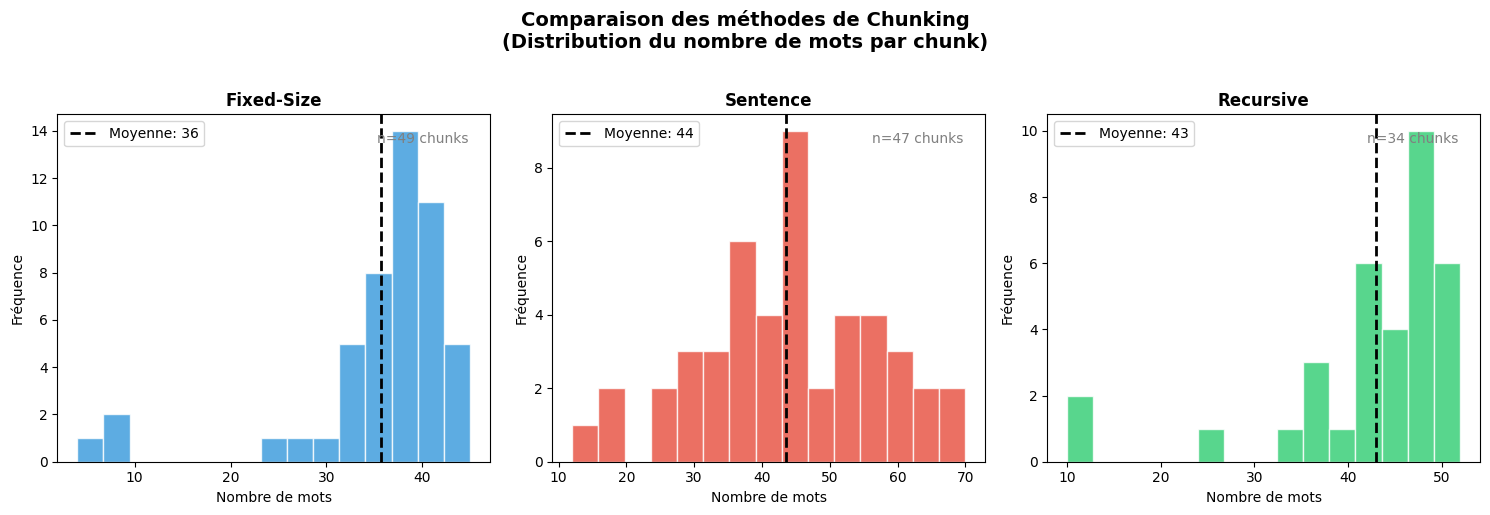


📊 TABLEAU RÉCAPITULATIF
Méthode          Nb Chunks    Moy. mots   Std mots
-------------------------------------------------------
Fixed-Size              49         35.7        8.5
Sentence                47         43.6       13.2
Recursive               34         42.9        9.8


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# ============================================================
# VISUALISATION : Comparaison des tailles de chunks
# selon les différentes méthodes
# ============================================================

# Appliquer les 3 méthodes sur tous les documents
tous_chunks = {'Fixed-Size': [], 'Sentence': [], 'Recursive': []}

for _, row in df.iterrows():
    texte = row['texte']

    # Méthode 1 : Fixed-size
    for c in fixed_size_chunking(texte, taille_chunk=300, overlap=50):
        tous_chunks['Fixed-Size'].append(len(c['texte'].split()))

    # Méthode 2 : Sentence
    for c in sentence_chunking(texte, phrases_par_chunk=3):
        tous_chunks['Sentence'].append(c['nb_mots'])

    # Méthode 3 : Recursive
    for c in recursive_chunking(texte, taille_max=350, overlap=50):
        tous_chunks['Recursive'].append(c['nb_mots'])

# Créer la figure
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Comparaison des méthodes de Chunking\n(Distribution du nombre de mots par chunk)',
             fontsize=14, fontweight='bold', y=1.02)

colors = ['#3498db', '#e74c3c', '#2ecc71']

for ax, (methode, tailles), color in zip(axes, tous_chunks.items(), colors):
    ax.hist(tailles, bins=15, color=color, alpha=0.8, edgecolor='white')
    ax.set_title(f'{methode}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Nombre de mots')
    ax.set_ylabel('Fréquence')

    # Statistiques
    mean_val = np.mean(tailles)
    ax.axvline(mean_val, color='black', linestyle='--', linewidth=2, label=f'Moyenne: {mean_val:.0f}')
    ax.legend()
    ax.text(0.95, 0.95, f'n={len(tailles)} chunks', transform=ax.transAxes,
            ha='right', va='top', fontsize=10, color='gray')

plt.tight_layout()
plt.savefig('chunking_comparison.png', bbox_inches='tight', dpi=150)
plt.show()

# Tableau récapitulatif
print('\n📊 TABLEAU RÉCAPITULATIF')
print('=' * 55)
print(f'{"Méthode":<15} {"Nb Chunks":>10} {"Moy. mots":>12} {"Std mots":>10}')
print('-' * 55)
for methode, tailles in tous_chunks.items():
    print(f'{methode:<15} {len(tailles):>10} {np.mean(tailles):>12.1f} {np.std(tailles):>10.1f}')

### 3.5 Application du chunking à tout le corpus

In [ ]:
# ============================================================
# APPLICATION : Chunker tous les documents avec la méthode
# Recursive (la plus adaptée pour un RAG de qualité)
# On garde les métadonnées (doc_id, titre, catégorie)
# pour pouvoir les retrouver lors de la recherche
# ============================================================

all_chunks = []  # Liste finale de tous les chunks avec métadonnées

for _, row in df.iterrows():
    # Créer les chunks pour ce document
    chunks = recursive_chunking(row['texte'], taille_max=400, overlap=60)

    for j, chunk in enumerate(chunks):
        # Enrichir chaque chunk avec les métadonnées du document parent
        chunk_enrichi = {
            'chunk_id': f"{row['id']}_chunk_{j:02d}",  # ID unique du chunk
            'doc_id': row['id'],                         # ID du document parent
            'titre': row['titre'],                       # Titre du document
            'categorie': row['categorie'],               # Catégorie
            'chunk_index': j,                            # Position dans le document
            'texte': chunk['texte'],                     # Texte du chunk
            'nb_mots': chunk['nb_mots'],
            'nb_caracteres': chunk['nb_caracteres']
        }
        all_chunks.append(chunk_enrichi)

# Convertir en DataFrame
df_chunks = pd.DataFrame(all_chunks)

print(f'✅ Corpus chunké : {len(df)} documents → {len(df_chunks)} chunks')
print(f'\n📊 Aperçu des chunks :')
print(df_chunks[['chunk_id', 'titre', 'nb_mots']].head(10).to_string(index=False))

print(f'\n📈 Distribution des chunks par document :')
print(df_chunks.groupby('titre')['chunk_id'].count().to_string())

✅ Corpus chunké : 8 documents → 32 chunks

📊 Aperçu des chunks :
        chunk_id                                       titre  nb_mots
doc_001_chunk_00            Introduction au Machine Learning       47
doc_001_chunk_01            Introduction au Machine Learning       48
doc_001_chunk_02            Introduction au Machine Learning       43
doc_001_chunk_03            Introduction au Machine Learning       23
doc_002_chunk_00 Les Réseaux de Neurones et le Deep Learning       49
doc_002_chunk_01 Les Réseaux de Neurones et le Deep Learning       45
doc_002_chunk_02 Les Réseaux de Neurones et le Deep Learning       56
doc_002_chunk_03 Les Réseaux de Neurones et le Deep Learning       49
doc_003_chunk_00       L'Architecture Transformer et les LLM       52
doc_003_chunk_01       L'Architecture Transformer et les LLM       52

📈 Distribution des chunks par document :
titre
Computer Vision et Traitement d'Images           4
Introduction au Machine Learning                 4
L'Architecture 

---
## 4. 🔢 Les Embeddings

### Qu'est-ce qu'un embedding ?

Un **embedding** est une représentation numérique (vecteur) d'un texte dans un espace de haute dimension.
L'objectif : **les textes sémantiquement similaires doivent avoir des vecteurs proches**.

```
Texte → Modèle d'Embedding → Vecteur [0.23, -0.45, 0.87, ..., 0.12]  (768 dimensions)

"Le chien aboie"     → [0.23, -0.45, 0.87, ...]
"Le chien crie"      → [0.21, -0.43, 0.89, ...]  ← proche !
"La table est ronde" → [-0.65, 0.12, -0.34, ...] ← loin !
```

### Types d'embeddings :
| Méthode | Année | Dimensions | Points forts |
|---------|-------|-----------|-------------|
| TF-IDF | 1972 | Variable | Simple, interprétable, rapide |
| Word2Vec | 2013 | 100-300 | Capture relations sémantiques |
| GloVe | 2014 | 50-300 | Entraîné sur statistiques globales |
| FastText | 2016 | 100-300 | Gère les mots inconnus |
| BERT | 2018 | 768 | Bidirectionnel, contextuel |
| Sentence-BERT | 2019 | 384-768 | **Optimal pour le RAG** |
| OpenAI Ada-002 | 2022 | 1536 | Très performant, payant |

### 4.1 TF-IDF (Term Frequency - Inverse Document Frequency)

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
import warnings
warnings.filterwarnings('ignore')

# ============================================================
# MÉTHODE 1 : TF-IDF
#
# TF (Term Frequency) = nombre de fois qu'un mot apparaît / total mots
# IDF (Inverse Doc Frequency) = log(total docs / docs contenant le mot)
# TF-IDF = TF × IDF → pénalise les mots très communs (le, la, de, ...)
#
# ✅ Avantages : pas de pré-entraînement, très rapide, interprétable
# ❌ Inconvénients : pas de sens sémantique (chat ≠ félin), sparse
# ============================================================

# Extraire tous les textes des chunks
textes_chunks = df_chunks['texte'].tolist()

# Créer le vectoriseur TF-IDF
# max_features : garder seulement les 5000 termes les plus importants
# stop_words : ignorer les mots courants en français
tfidf_vectorizer = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2),     # Inclure les bigrammes (paires de mots)
    min_df=2,               # Ignorer les termes qui apparaissent dans < 2 docs
    sublinear_tf=True       # Appliquer log sur TF pour réduire l'impact des répétitions
)

# Entraîner le vectoriseur et transformer tous les chunks en vecteurs
tfidf_matrix = tfidf_vectorizer.fit_transform(textes_chunks)

print(f'🔢 Matrice TF-IDF : {tfidf_matrix.shape}')
print(f'   → {tfidf_matrix.shape[0]} chunks × {tfidf_matrix.shape[1]} features')
print(f'   → Densité : {tfidf_matrix.nnz / (tfidf_matrix.shape[0] * tfidf_matrix.shape[1]):.4f} (matrice sparse !)')

# Démonstration : recherche par similarité cosinus
def recherche_tfidf(requete, top_k=3):
    """
    Recherche les chunks les plus similaires à une requête.
    Similarité cosinus : mesure l'angle entre 2 vecteurs (0=opposés, 1=identiques)
    """
    # Transformer la requête avec le même vectoriseur
    vecteur_requete = tfidf_vectorizer.transform([requete])

    # Calculer la similarité cosinus entre la requête et tous les chunks
    scores = cosine_similarity(vecteur_requete, tfidf_matrix).flatten()

    # Trier par score décroissant et prendre les top_k
    indices_tries = np.argsort(scores)[::-1][:top_k]

    return [(df_chunks.iloc[i]['texte'], scores[i], df_chunks.iloc[i]['titre'])
            for i in indices_tries]

# Test de recherche
requete = "comment les réseaux de neurones apprennent-ils ?"
resultats = recherche_tfidf(requete)

print(f'\n🔍 Requête : "{requete}"')
print('=' * 60)
for i, (texte, score, titre) in enumerate(resultats):
    print(f'\n📌 Résultat {i+1} (score: {score:.4f}) — {titre}')
    print(f'   {texte[:200]}...')

🔢 Matrice TF-IDF : (32, 280)
   → 32 chunks × 280 features
   → Densité : 0.1066 (matrice sparse !)

🔍 Requête : "comment les réseaux de neurones apprennent-ils ?"

📌 Résultat 1 (score: 0.5283) — Les Réseaux de Neurones et le Deep Learning
   Les réseaux de neurones artificiels s'inspirent du fonctionnement du cerveau humain.
Ils sont composés de couches de neurones artificiels connectés entre eux par des poids.
Le deep learning (apprentis...

📌 Résultat 2 (score: 0.2536) — Reinforcement Learning et Agents Intelligents
   (pour maximiser les récompenses immédiates) ou explore de nouvelles actions
(pour potentiellement découvrir de meilleures stratégies à long terme).
Q-Learning est l'algorithme fondamental du RL. Il ap...

📌 Résultat 3 (score: 0.1539) — Les Réseaux de Neurones et le Deep Learning
   de l'erreur par rapport à chaque poids du réseau, permettant de les ajuster
pour minimiser l'erreur de prédiction. L'optimiseur Adam est aujourd'hui
le plus utilisé car il adapte automatiqu

### 4.2 Sentence Transformers (état de l'art)

In [ ]:
from sentence_transformers import SentenceTransformer
import time

# ============================================================
# MÉTHODE 2 : Sentence Transformers (SBERT)
#
# Basé sur BERT, fine-tuné pour générer des embeddings de phrases
# Utilise du mean-pooling sur les tokens pour obtenir 1 vecteur par phrase
#
# Modèle 'all-MiniLM-L6-v2' :
# - 22M paramètres (très léger)
# - 384 dimensions
# - Supporte 50+ langues
# - Parfait pour débuter avec le RAG
#
# Pour le français :
# - 'paraphrase-multilingual-MiniLM-L12-v2' (multilingue)
# - 'dangvantuan/vietnamese-embedding' → adapter pour d'autres langues
#
# ✅ Avantages : capture le sens sémantique profond, dense vectors
# ✅ Performances SOTA sur les benchmarks de recherche sémantique
# ❌ Inconvénients : nécessite GPU pour la production, plus lent que TF-IDF
# ============================================================

print('⏳ Chargement du modèle Sentence Transformer...')

# Charger un modèle multilingue (supporte le français !)
modele_embedding = SentenceTransformer('paraphrase-multilingual-MiniLM-L12-v2')

print(f'✅ Modèle chargé : paraphrase-multilingual-MiniLM-L12-v2')
print(f'   Dimension des embeddings : {modele_embedding.get_sentence_embedding_dimension()}')

# ============================================================
# Générer les embeddings pour tous les chunks
# batch_size=32 : traiter 32 chunks à la fois (optimisation mémoire)
# show_progress_bar : afficher une barre de progression
# ============================================================

print('\n⏳ Génération des embeddings pour tous les chunks...')
debut = time.time()

embeddings = modele_embedding.encode(
    textes_chunks,
    batch_size=32,
    show_progress_bar=True,
    normalize_embeddings=True  # Normaliser pour utiliser le produit scalaire comme similarité
)

duree = time.time() - debut
print(f'\n✅ Embeddings générés !')
print(f'   Shape : {embeddings.shape}  ({embeddings.shape[0]} chunks × {embeddings.shape[1]} dimensions)')
print(f'   Temps : {duree:.2f}s ({duree/len(textes_chunks)*1000:.1f}ms par chunk)')
print(f'   Taille mémoire : {embeddings.nbytes / 1024:.1f} KB')

⏳ Chargement du modèle Sentence Transformer...


modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

✅ Modèle chargé : paraphrase-multilingual-MiniLM-L12-v2
   Dimension des embeddings : 384

⏳ Génération des embeddings pour tous les chunks...


Batches:   0%|          | 0/1 [00:00<?, ?it/s]


✅ Embeddings générés !
   Shape : (32, 384)  (32 chunks × 384 dimensions)
   Temps : 4.02s (125.7ms par chunk)
   Taille mémoire : 48.0 KB


### 4.3 Visualisation des Embeddings

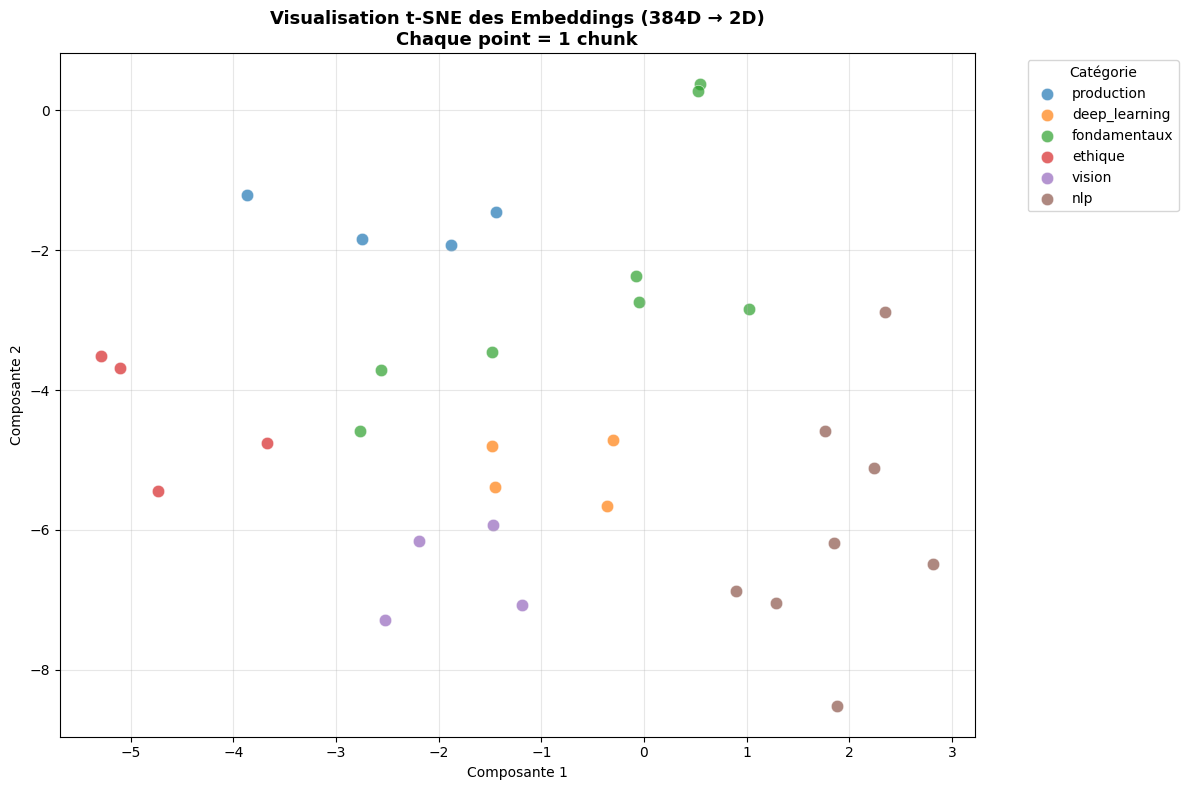

💡 Observation : les chunks de même catégorie devraient être regroupés !
   C'est la preuve que les embeddings capturent le sens sémantique.


In [ ]:
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# ============================================================
# VISUALISATION : Réduire les embeddings de 384D → 2D
# pour les visualiser sur un plan
#
# PCA (Principal Component Analysis) : réduction linéaire
# t-SNE : réduction non-linéaire, préserve mieux les clusters
# ============================================================

# Étape 1 : PCA de 384D → 50D (t-SNE fonctionne mieux sur peu de dims)
# Fix: n_components should be less than or equal to n_samples (len(embeddings)).
# Here, len(embeddings) is 32, so n_components must be <= 32. Using min(50, len(embeddings)-1) for safety.
pca = PCA(n_components=min(50, len(embeddings) - 1), random_state=42)
embeddings_pca50 = pca.fit_transform(embeddings)

# Étape 2 : t-SNE de 50D → 2D pour la visualisation
tsne = TSNE(n_components=2, random_state=42, perplexity=min(15, len(embeddings)-1))
embeddings_2d = tsne.fit_transform(embeddings_pca50)

# Créer la figure
fig, ax = plt.subplots(1, 1, figsize=(12, 8))

# Couleurs par catégorie de document
categories = df_chunks['categorie'].tolist()
categories_uniques = list(set(categories))
palette = plt.cm.tab10.colors
couleur_map = {cat: palette[i] for i, cat in enumerate(categories_uniques)}

# Tracer chaque chunk
for cat in categories_uniques:
    indices = [i for i, c in enumerate(categories) if c == cat]
    x = embeddings_2d[indices, 0]
    y = embeddings_2d[indices, 1]
    ax.scatter(x, y, c=[couleur_map[cat]], label=cat, alpha=0.7, s=80, edgecolors='white', linewidth=0.5)

ax.set_title('Visualisation t-SNE des Embeddings (384D → 2D)\nChaque point = 1 chunk',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Composante 1')
ax.set_ylabel('Composante 2')
ax.legend(title='Catégorie', bbox_to_anchor=(1.05, 1), loc='upper left')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('embeddings_tsne.png', bbox_inches='tight', dpi=150)
plt.show()

print('💡 Observation : les chunks de même catégorie devraient être regroupés !')
print('   C\'est la preuve que les embeddings capturent le sens sémantique.')

### 4.4 Mesures de Similarité

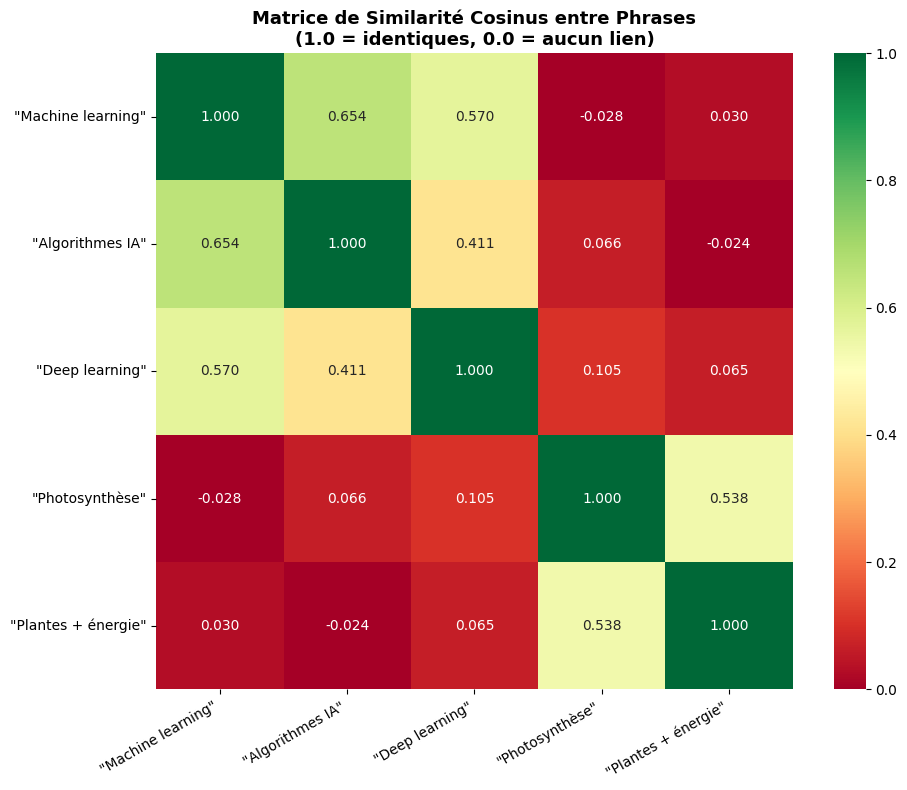

✅ Observation attendue :
   - Les 3 phrases sur l'IA devraient avoir une haute similarité entre elles
   - Les 2 phrases sur les plantes devraient être similaires entre elles
   - IA ↔ Plantes devrait avoir une faible similarité


In [ ]:
import seaborn as sns

# ============================================================
# LES 3 MESURES DE SIMILARITÉ POUR LES VECTEURS
#
# 1. Similarité Cosinus : mesure l'angle entre 2 vecteurs
#    cos(θ) = (A·B) / (|A| × |B|)
#    Valeur entre -1 et 1 (1 = identiques, 0 = orthogonaux)
#    → Recommandé pour les embeddings texte !
#
# 2. Distance Euclidienne : distance en ligne droite
#    d = √Σ(ai - bi)²
#    Plus petite = plus similaire
#    → Bien si embeddings normalisés (équivalent au cosinus)
#
# 3. Produit Scalaire (Dot Product) : A·B = Σ(ai × bi)
#    → Équivalent au cosinus si vecteurs normalisés
#    → Très rapide à calculer (FAISS l'utilise)
# ============================================================

# Démonstration avec des phrases exemples
phrases_demo = [
    "Le machine learning permet aux machines d'apprendre",
    "Les algorithmes d'IA apprennent à partir des données",
    "Le deep learning utilise des réseaux de neurones profonds",
    "La photosynthèse est un processus biologique",
    "Les plantes utilisent la lumière solaire pour produire de l'énergie"
]

# Générer les embeddings
emb_demo = modele_embedding.encode(phrases_demo, normalize_embeddings=True)

# Calculer la matrice de similarité cosinus
sim_matrix = cosine_similarity(emb_demo)

# Visualiser
fig, ax = plt.subplots(figsize=(10, 8))

labels_courts = [
    '"Machine learning"',
    '"Algorithmes IA"',
    '"Deep learning"',
    '"Photosynthèse"',
    '"Plantes + énergie"'
]

sns.heatmap(
    sim_matrix,
    xticklabels=labels_courts,
    yticklabels=labels_courts,
    annot=True,
    fmt='.3f',
    cmap='RdYlGn',
    vmin=0, vmax=1,
    ax=ax,
    square=True
)

ax.set_title('Matrice de Similarité Cosinus entre Phrases\n(1.0 = identiques, 0.0 = aucun lien)',
             fontsize=13, fontweight='bold')
plt.xticks(rotation=30, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('similarity_matrix.png', bbox_inches='tight', dpi=150)
plt.show()

print('✅ Observation attendue :')
print('   - Les 3 phrases sur l\'IA devraient avoir une haute similarité entre elles')
print('   - Les 2 phrases sur les plantes devraient être similaires entre elles')
print('   - IA ↔ Plantes devrait avoir une faible similarité')

---
## 5. 🗄️ Base de Données Vectorielle

Une **base de données vectorielle** stocke les embeddings et permet une **recherche ultra-rapide** par similarité.

### Comparaison des solutions :

| Solution | Type | Avantages | Usage |
|----------|------|-----------|-------|
| Notre implémentation | From scratch | Pédagogique | Apprentissage |
| FAISS | Bibliothèque | Ultra-rapide, scalable | Production (millions de vecteurs) |
| ChromaDB | Base de données | Simple, persistant, filtres | Projets RAG |
| Pinecone | Cloud | Managé, haute dispo | Production SaaS |
| Weaviate | Base de données | GraphQL, hybride | Enterprise |
| Qdrant | Base de données | Rust, rapide, filtres | Production moderne |


### 5.1 VectorDB From Scratch

In [ ]:
# ============================================================
# IMPLÉMENTATION FROM SCRATCH : VectorDB minimale
# Pour comprendre le fonctionnement interne
# ============================================================

class SimpleVectorDB:
    """
    Base de données vectorielle simple implémentée from scratch.
    Utilise une recherche par force brute (calcul de similarité
    avec tous les vecteurs stockés).

    Complexité : O(n) par requête (n = nombre de vecteurs)
    OK pour < 10 000 vecteurs, trop lent au-delà.
    """

    def __init__(self):
        """Initialiser les structures de données."""
        self.vecteurs = []       # Liste des embeddings numpy
        self.metadonnees = []    # Liste des métadonnées associées
        self.dimension = None    # Dimension des vecteurs (vérification)

    def ajouter(self, vecteur, metadata):
        """
        Ajouter un vecteur avec ses métadonnées.
        vecteur  : numpy array de dimension D
        metadata : dict avec les infos (texte, doc_id, titre, etc.)
        """
        # Vérifier que la dimension est cohérente
        if self.dimension is None:
            self.dimension = len(vecteur)
        elif len(vecteur) != self.dimension:
            raise ValueError(f'Dimension attendue : {self.dimension}, reçue : {len(vecteur)}')

        # Normaliser le vecteur (pour que le produit scalaire = cosinus)
        norme = np.linalg.norm(vecteur)
        vecteur_normalise = vecteur / (norme + 1e-10)  # 1e-10 évite la division par zéro

        self.vecteurs.append(vecteur_normalise)
        self.metadonnees.append(metadata)

    def ajouter_batch(self, vecteurs, metadonnees_list):
        """Ajouter plusieurs vecteurs en une fois (plus efficace)."""
        for vecteur, meta in zip(vecteurs, metadonnees_list):
            self.ajouter(vecteur, meta)
        print(f'✅ {len(vecteurs)} vecteurs ajoutés. Total : {len(self.vecteurs)}')

    def rechercher(self, vecteur_requete, top_k=5, seuil_min=0.0):
        """
        Rechercher les top_k vecteurs les plus similaires.

        Algorithme :
        1. Normaliser le vecteur requête
        2. Calculer le produit scalaire avec TOUS les vecteurs (= cosinus)
        3. Trier par score décroissant
        4. Retourner les top_k avec leurs métadonnées
        """
        if not self.vecteurs:
            return []

        # Normaliser la requête
        norme = np.linalg.norm(vecteur_requete)
        requete_normalisee = vecteur_requete / (norme + 1e-10)

        # Convertir la liste de vecteurs en matrice numpy (pour vectoriser le calcul)
        matrice = np.array(self.vecteurs)  # Shape : (n_vecteurs, dimension)

        # Produit scalaire = similarité cosinus (car vecteurs normalisés)
        # matrice @ requete = calcul matriciel → résultat en une opération !
        scores = matrice @ requete_normalisee  # Shape : (n_vecteurs,)

        # Trier par score décroissant
        indices_tries = np.argsort(scores)[::-1]

        # Filtrer par seuil et prendre les top_k
        resultats = []
        for idx in indices_tries:
            if len(resultats) >= top_k:
                break
            if scores[idx] >= seuil_min:
                resultats.append({
                    'score': float(scores[idx]),
                    'metadata': self.metadonnees[idx]
                })

        return resultats

    def __len__(self):
        return len(self.vecteurs)

    def __repr__(self):
        return f'SimpleVectorDB({len(self.vecteurs)} vecteurs, dim={self.dimension})'


# Créer la base et y insérer tous nos chunks
db_scratch = SimpleVectorDB()

# Préparer les métadonnées
metadonnees_list = df_chunks.to_dict('records')

# Insérer tous les embeddings
db_scratch.ajouter_batch(embeddings, metadonnees_list)
print(db_scratch)

✅ 32 vecteurs ajoutés. Total : 32
SimpleVectorDB(32 vecteurs, dim=384)


### 5.2 FAISS — Facebook AI Similarity Search

In [ ]:
import faiss

# ============================================================
# FAISS : Bibliothèque ultra-optimisée pour la recherche de vecteurs
# Développée par Facebook/Meta Research
#
# PRINCIPAUX INDEX FAISS :
#
# IndexFlatL2      : distance L2 exacte, force brute
#                    → Précision parfaite, lent sur gros volumes
#
# IndexFlatIP      : produit scalaire exact (Inner Product)
#                    → Utilisé avec vecteurs normalisés = cosinus
#
# IndexIVFFlat     : Inverted File Index
#                    → Divise l'espace en clusters (k-means)
#                    → Recherche seulement dans les clusters proches
#                    → 10-100x plus rapide, légèrement moins précis
#
# IndexHNSW        : Hierarchical Navigable Small World
#                    → Graphe de navigation hiérarchique
#                    → Très rapide en requête, bonne précision
#
# IndexIVFPQ       : IVF + Product Quantization (compression)
#                    → Vecteurs compressés, très léger en mémoire
# ============================================================

# Dimension des embeddings
dimension = embeddings.shape[1]  # 384

# S'assurer que les embeddings sont en float32 (requis par FAISS)
embeddings_f32 = embeddings.astype(np.float32)

# ---- INDEX 1 : Flat L2 (exact, force brute) ----
index_flat = faiss.IndexFlatL2(dimension)
index_flat.add(embeddings_f32)
print(f'✅ Index FlatL2 créé : {index_flat.ntotal} vecteurs')

# ---- INDEX 2 : Flat IP (produit scalaire = cosinus pour vecteurs normalisés) ----
index_ip = faiss.IndexFlatIP(dimension)
index_ip.add(embeddings_f32)
print(f'✅ Index FlatIP créé : {index_ip.ntotal} vecteurs')

# ---- INDEX 3 : IVF (approché, plus rapide) ----
# nlist = nombre de clusters (√n est une bonne heuristique)
nlist = max(4, int(np.sqrt(len(embeddings_f32))))
quantizer = faiss.IndexFlatL2(dimension)  # Quantifier utilisé pour k-means
index_ivf = faiss.IndexIVFFlat(quantizer, dimension, nlist)

# IMPORTANT : entraîner l'index IVF avant d'ajouter des vecteurs
# (crée les clusters k-means)
index_ivf.train(embeddings_f32)
index_ivf.add(embeddings_f32)
index_ivf.nprobe = 3  # Nombre de clusters à explorer lors de la recherche
print(f'✅ Index IVF créé : {index_ivf.ntotal} vecteurs, {nlist} clusters')


# ---- Comparaison des performances ----
def recherche_faiss(index, requete_embedding, top_k=3, index_name=""):
    """
    Effectuer une recherche avec un index FAISS.
    Retourne les top_k vecteurs les plus proches.
    """
    # FAISS attend un tableau 2D : (1, dimension)
    requete = requete_embedding.reshape(1, -1).astype(np.float32)

    debut = time.time()
    # distances : scores de similarité (L2) ou produit scalaire
    # indices   : indices des vecteurs trouvés dans notre matrice
    distances, indices = index.search(requete, top_k)
    duree = (time.time() - debut) * 1000

    print(f'\n⏱️  {index_name} : {duree:.3f}ms')
    for i, (dist, idx) in enumerate(zip(distances[0], indices[0])):
        chunk = df_chunks.iloc[idx]
        print(f'  {i+1}. [score={dist:.4f}] {chunk["titre"]} | {chunk["texte"][:80]}...')


# Test de recherche
requete_test = "comment fonctionne l'attention dans les transformers ?"
emb_requete = modele_embedding.encode([requete_test], normalize_embeddings=True)[0]

print(f'🔍 Requête : "{requete_test}"')
print('=' * 70)

recherche_faiss(index_flat, emb_requete, top_k=3, index_name="IndexFlatL2")
recherche_faiss(index_ip, emb_requete, top_k=3, index_name="IndexFlatIP")
recherche_faiss(index_ivf, emb_requete, top_k=3, index_name="IndexIVFFlat")

✅ Index FlatL2 créé : 32 vecteurs
✅ Index FlatIP créé : 32 vecteurs
✅ Index IVF créé : 32 vecteurs, 5 clusters
🔍 Requête : "comment fonctionne l'attention dans les transformers ?"

⏱️  IndexFlatL2 : 0.107ms
  1. [score=0.7143] L'Architecture Transformer et les LLM | L'architecture Transformer, introduite en 2017 par l'article 'Attention Is All Y...
  2. [score=1.0819] Les Réseaux de Neurones et le Deep Learning | de l'erreur par rapport à chaque poids du réseau, permettant de les ajuster
pour...
  3. [score=1.1520] Les Réseaux de Neurones et le Deep Learning | La couche d'entrée reçoit les données brutes (pixels d'une image, mots d'une phr...

⏱️  IndexFlatIP : 0.129ms
  1. [score=0.6428] L'Architecture Transformer et les LLM | L'architecture Transformer, introduite en 2017 par l'article 'Attention Is All Y...
  2. [score=0.4590] Les Réseaux de Neurones et le Deep Learning | de l'erreur par rapport à chaque poids du réseau, permettant de les ajuster
pour...
  3. [score=0.4240] Les Rése

### 5.3 ChromaDB — Base vectorielle avec persistance

In [ ]:
import chromadb
from chromadb.config import Settings

# ============================================================
# CHROMADB : Base de données vectorielle open-source
#
# Avantages par rapport à FAISS :
# ✅ Persistance sur disque (les données survivent au redémarrage)
# ✅ Gestion des métadonnées et filtrage
# ✅ API simple et intuitive
# ✅ Intégré avec LangChain, LlamaIndex
# ✅ Interface web disponible
# ============================================================

# Créer un client ChromaDB en mémoire (pour ce notebook)
# Pour la persistance sur disque :
# client = chromadb.PersistentClient(path='./ma_base_vectorielle')
client = chromadb.Client()

# Créer une collection (= une table dans une BD classique)
# On peut avoir plusieurs collections pour différents ensembles de documents
collection = client.create_collection(
    name='cours_ia',
    metadata={'description': 'Documents sur l\'Intelligence Artificielle'}
)

# Insérer tous les chunks dans ChromaDB
# ChromaDB accepte :
# - ids        : identifiants uniques (obligatoires)
# - documents  : textes bruts
# - embeddings : vecteurs pré-calculés
# - metadatas  : métadonnées pour le filtrage

print('⏳ Insertion des chunks dans ChromaDB...')

# Insérer en batch de 50 (limite de ChromaDB par requête)
batch_size = 50
for i in range(0, len(df_chunks), batch_size):
    batch = df_chunks.iloc[i:i+batch_size]

    collection.add(
        ids=batch['chunk_id'].tolist(),
        documents=batch['texte'].tolist(),
        embeddings=embeddings[i:i+batch_size].tolist(),  # Nos embeddings pré-calculés
        metadatas=[
            {
                'doc_id': row['doc_id'],
                'titre': row['titre'],
                'categorie': row['categorie'],
                'chunk_index': int(row['chunk_index'])
            }
            for _, row in batch.iterrows()
        ]
    )

print(f'✅ Collection créée : {collection.count()} chunks indexés')

# ---- Recherche simple ----
resultats = collection.query(
    query_embeddings=[emb_requete.tolist()],
    n_results=3
)

print(f'\n🔍 Requête : "{requete_test}"')
print('=' * 60)
for i, (doc, meta, dist) in enumerate(zip(
    resultats['documents'][0],
    resultats['metadatas'][0],
    resultats['distances'][0]
)):
    print(f'\n📌 Résultat {i+1} [distance={dist:.4f}] — {meta["titre"]}')
    print(f'   {doc[:150]}...')

⏳ Insertion des chunks dans ChromaDB...
✅ Collection créée : 32 chunks indexés

🔍 Requête : "comment fonctionne l'attention dans les transformers ?"

📌 Résultat 1 [distance=0.7143] — L'Architecture Transformer et les LLM
   L'architecture Transformer, introduite en 2017 par l'article 'Attention Is All You Need',
a révolutionné le traitement du langage naturel (NLP).
Elle ...

📌 Résultat 2 [distance=1.0819] — Les Réseaux de Neurones et le Deep Learning
   de l'erreur par rapport à chaque poids du réseau, permettant de les ajuster
pour minimiser l'erreur de prédiction. L'optimiseur Adam est aujourd'hui
l...

📌 Résultat 3 [distance=1.1520] — Les Réseaux de Neurones et le Deep Learning
   La couche d'entrée reçoit les données brutes (pixels d'une image, mots d'une phrase).
Les couches cachées transforment progressivement la représentati...


In [ ]:
# ---- Recherche avec FILTRAGE par métadonnées ----
# C'est l'un des grands avantages de ChromaDB par rapport à FAISS pur

print('🔍 Recherche avec filtre sur la catégorie "nlp" uniquement :')
print('=' * 60)

resultats_filtres = collection.query(
    query_embeddings=[emb_requete.tolist()],
    n_results=3,
    where={'categorie': 'nlp'}  # Filtre : seulement les docs NLP
)

for i, (doc, meta, dist) in enumerate(zip(
    resultats_filtres['documents'][0],
    resultats_filtres['metadatas'][0],
    resultats_filtres['distances'][0]
)):
    print(f'\n📌 Résultat {i+1} [dist={dist:.4f}] — {meta["titre"]} (cat: {meta["categorie"]})')
    print(f'   {doc[:150]}...')

print('\n💡 Les filtres ChromaDB permettent de chercher dans un sous-ensemble')
print('   Ex: filtrer par date, auteur, source, département, etc.')

🔍 Recherche avec filtre sur la catégorie "nlp" uniquement :

📌 Résultat 1 [dist=0.7143] — L'Architecture Transformer et les LLM (cat: nlp)
   L'architecture Transformer, introduite en 2017 par l'article 'Attention Is All You Need',
a révolutionné le traitement du langage naturel (NLP).
Elle ...

📌 Résultat 2 [dist=1.2345] — L'Architecture Transformer et les LLM (cat: nlp)
   de capturer différents types de relations entre les mots simultanément.
Certaines têtes capturent les relations syntaxiques, d'autres les relations sé...

📌 Résultat 3 [dist=1.2678] — L'Architecture Transformer et les LLM (cat: nlp)
   pour mieux comprendre le contexte de chaque mot.
GPT (Generative Pre-trained Transformer) d'OpenAI est un modèle autorégressif
qui prédit le prochain ...

💡 Les filtres ChromaDB permettent de chercher dans un sous-ensemble
   Ex: filtrer par date, auteur, source, département, etc.


---
## 6. 🚀 Pipeline RAG Complet

Assemblons toutes les pièces pour créer un système RAG fonctionnel !

In [ ]:
# ============================================================
# PIPELINE RAG COMPLET
#
# Étapes :
# 1. [INDEXATION - fait une seule fois]
#    Documents → Chunking → Embedding → VectorDB
#
# 2. [REQUÊTE - fait à chaque question]
#    Question → Embedding → Recherche similaire → Contexte → LLM → Réponse
#
# Dans ce notebook, on simule le LLM par une fonction simple
# En production : GPT-4, Claude, Llama, Mistral, etc.
# ============================================================

class RAGSystem:
    """
    Système RAG complet combinant :
    - Chunking récursif
    - Embeddings Sentence Transformers
    - Recherche FAISS
    - Génération de réponse (simulée)
    """

    def __init__(self, modele_nom='paraphrase-multilingual-MiniLM-L12-v2'):
        """Initialiser le système RAG."""
        print('🔧 Initialisation du système RAG...')

        # Charger le modèle d'embedding
        self.modele = SentenceTransformer(modele_nom)
        self.dimension = self.modele.get_sentence_embedding_dimension()

        # Créer l'index FAISS (produit scalaire pour vecteurs normalisés)
        self.index = faiss.IndexFlatIP(self.dimension)

        # Stocker les métadonnées
        self.chunks_data = []

        print(f'✅ Prêt ! Modèle : {modele_nom}, Dim : {self.dimension}')

    def indexer_documents(self, documents_list, taille_chunk=400, overlap=60):
        """
        PHASE D'INDEXATION :
        1. Chunker tous les documents
        2. Générer les embeddings
        3. Indexer dans FAISS
        """
        print('\n📥 Indexation des documents...')
        tous_textes = []
        toutes_metas = []

        for doc in documents_list:
            # Étape 1 : Chunking
            chunks = recursive_chunking(doc['texte'], taille_max=taille_chunk, overlap=overlap)

            for j, chunk in enumerate(chunks):
                tous_textes.append(chunk['texte'])
                toutes_metas.append({
                    'doc_id': doc['id'],
                    'titre': doc['titre'],
                    'categorie': doc['categorie'],
                    'texte': chunk['texte'],
                    'chunk_index': j
                })

        print(f'   ✂️  {len(documents_list)} documents → {len(tous_textes)} chunks')

        # Étape 2 : Générer les embeddings
        print('   🔢 Génération des embeddings...')
        embs = self.modele.encode(tous_textes, normalize_embeddings=True,
                                   batch_size=32, show_progress_bar=True)

        # Étape 3 : Indexer dans FAISS
        self.index.add(embs.astype(np.float32))
        self.chunks_data.extend(toutes_metas)

        print(f'\n✅ Indexation terminée : {self.index.ntotal} chunks dans FAISS')

    def rechercher(self, requete, top_k=5, seuil_min=0.3):
        """
        PHASE DE RECHERCHE :
        1. Encoder la requête
        2. Trouver les chunks les plus similaires
        """
        # Encoder la requête
        emb_requete = self.modele.encode([requete], normalize_embeddings=True)[0]
        requete_f32 = emb_requete.reshape(1, -1).astype(np.float32)

        # Recherche FAISS
        scores, indices = self.index.search(requete_f32, min(top_k * 2, self.index.ntotal))

        # Filtrer par seuil et dédupliquer par document
        resultats = []
        docs_vus = set()

        for score, idx in zip(scores[0], indices[0]):
            if idx == -1 or score < seuil_min:
                continue

            chunk = self.chunks_data[idx]

            # Option : dédupliquer (une seule entrée par doc source)
            # if chunk['doc_id'] in docs_vus:
            #     continue
            # docs_vus.add(chunk['doc_id'])

            resultats.append({
                'score': float(score),
                'texte': chunk['texte'],
                'titre': chunk['titre'],
                'doc_id': chunk['doc_id'],
                'categorie': chunk['categorie']
            })

            if len(resultats) >= top_k:
                break

        return resultats

    def construire_contexte(self, chunks_trouves):
        """
        Assembler les chunks récupérés en un contexte pour le LLM.
        Stratégie simple : concaténer les chunks triés par score.
        """
        if not chunks_trouves:
            return "Aucun document pertinent trouvé."

        lignes_contexte = []
        for i, chunk in enumerate(chunks_trouves):
            lignes_contexte.append(
                f"[Source {i+1}: {chunk['titre']} (pertinence: {chunk['score']:.2f})]\n"
                f"{chunk['texte']}"
            )

        return "\n\n---\n\n".join(lignes_contexte)

    def construire_prompt(self, requete, contexte):
        """
        Construire le prompt pour le LLM.
        Format standard pour un système RAG.
        """
        return f"""Tu es un assistant expert en intelligence artificielle.
Réponds à la question en te basant UNIQUEMENT sur les extraits de documents fournis.
Si la réponse ne se trouve pas dans les documents, dis-le clairement.
Cite les sources en indiquant le titre du document.

=== DOCUMENTS PERTINENTS ===
{contexte}

=== QUESTION ===
{requete}

=== RÉPONSE ==="""

    def repondre(self, requete, top_k=3, verbose=True):
        """
        Pipeline RAG complet pour répondre à une question.
        """
        if verbose:
            print(f'\n❓ Question : "{requete}"')
            print('=' * 70)

        # ÉTAPE 1 : Recherche des chunks pertinents
        chunks = self.rechercher(requete, top_k=top_k)

        if verbose:
            print(f'\n📚 {len(chunks)} chunks pertinents trouvés :')
            for i, c in enumerate(chunks):
                print(f'   {i+1}. [{c["score"]:.3f}] {c["titre"]} | {c["texte"][:80]}...')

        # ÉTAPE 2 : Construire le contexte
        contexte = self.construire_contexte(chunks)

        # ÉTAPE 3 : Construire le prompt
        prompt = self.construire_prompt(requete, contexte)

        if verbose:
            print(f'\n📝 Prompt envoyé au LLM ({len(prompt)} caractères)')

        # ÉTAPE 4 : [SIMULATION] Dans un vrai système, appel API au LLM ici
        # Exemple avec OpenAI :
        # response = openai.chat.completions.create(
        #     model='gpt-4',
        #     messages=[{'role': 'user', 'content': prompt}]
        # )
        # reponse = response.choices[0].message.content

        # SIMULATION : On retourne le prompt (à remplacer par l'appel LLM)
        reponse_simulee = (
            f"[SIMULATION LLM]\n"
            f"D'après les sources retrouvées ({len(chunks)} chunks pertinents),\n"
            f"la réponse à '{requete}' se trouve dans : \n"
            + "\n".join([f"- {c['titre']} (score: {c['score']:.3f})" for c in chunks])
        )

        return {
            'requete': requete,
            'chunks_sources': chunks,
            'contexte': contexte,
            'prompt': prompt,
            'reponse': reponse_simulee
        }


print('✅ Classe RAGSystem définie !')

✅ Classe RAGSystem définie !


In [ ]:
# ============================================================
# MISE EN PRATIQUE : Créer et utiliser le système RAG
# ============================================================

# Initialiser le système
rag = RAGSystem()

# Indexer tous nos documents
rag.indexer_documents(documents, taille_chunk=400, overlap=60)

🔧 Initialisation du système RAG...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


✅ Prêt ! Modèle : paraphrase-multilingual-MiniLM-L12-v2, Dim : 384

📥 Indexation des documents...
   ✂️  8 documents → 32 chunks
   🔢 Génération des embeddings...


Batches:   0%|          | 0/1 [00:00<?, ?it/s]


✅ Indexation terminée : 32 chunks dans FAISS


In [ ]:
# ============================================================
# TEST DU SYSTÈME RAG
# ============================================================

# Questions de test couvrant différents domaines
questions = [
    "Comment fonctionne le mécanisme d'attention dans les Transformers ?",
    "Quels sont les risques éthiques des algorithmes d'IA ?",
    "Qu'est-ce que le reinforcement learning ?",
    "Comment détecter des objets dans une image ?",
]

for question in questions:
    resultat = rag.repondre(question, top_k=3, verbose=True)
    print(f'\n💬 RÉPONSE GÉNÉRÉE :')
    print(resultat['reponse'])
    print('\n' + '─' * 70)


❓ Question : "Comment fonctionne le mécanisme d'attention dans les Transformers ?"

📚 3 chunks pertinents trouvés :
   1. [0.672] L'Architecture Transformer et les LLM | L'architecture Transformer, introduite en 2017 par l'article 'Attention Is All Y...
   2. [0.413] Les Réseaux de Neurones et le Deep Learning | de l'erreur par rapport à chaque poids du réseau, permettant de les ajuster
pour...
   3. [0.402] L'Architecture Transformer et les LLM | de capturer différents types de relations entre les mots simultanément.
Certaine...

📝 Prompt envoyé au LLM (1747 caractères)

💬 RÉPONSE GÉNÉRÉE :
[SIMULATION LLM]
D'après les sources retrouvées (3 chunks pertinents),
la réponse à 'Comment fonctionne le mécanisme d'attention dans les Transformers ?' se trouve dans : 
- L'Architecture Transformer et les LLM (score: 0.672)
- Les Réseaux de Neurones et le Deep Learning (score: 0.413)
- L'Architecture Transformer et les LLM (score: 0.402)

────────────────────────────────────────────────────────

In [ ]:
# ============================================================
# AFFICHER LE PROMPT COMPLET (pour comprendre ce qui est envoyé au LLM)
# ============================================================

question_demo = "Qu'est-ce que BERT et comment diffère-t-il de GPT ?"
resultat_demo = rag.repondre(question_demo, top_k=3, verbose=False)

print('📋 PROMPT COMPLET ENVOYÉ AU LLM :')
print('=' * 70)
print(resultat_demo['prompt'])
print('=' * 70)
print(f'\n📏 Longueur du prompt : {len(resultat_demo["prompt"])} caractères')
print(f'💡 Dans un vrai système, ce prompt serait envoyé à GPT-4, Claude, Llama, etc.')

📋 PROMPT COMPLET ENVOYÉ AU LLM :
Tu es un assistant expert en intelligence artificielle.
Réponds à la question en te basant UNIQUEMENT sur les extraits de documents fournis.
Si la réponse ne se trouve pas dans les documents, dis-le clairement.
Cite les sources en indiquant le titre du document.

=== DOCUMENTS PERTINENTS ===
[Source 1: L'Architecture Transformer et les LLM (pertinence: 0.58)]
pour mieux comprendre le contexte de chaque mot.
GPT (Generative Pre-trained Transformer) d'OpenAI est un modèle autorégressif
qui prédit le prochain token à partir des tokens précédents.
GPT-4 possède environ 1 trillion de paramètres et démontre des capacités
de raisonnement et de génération de texte remarquables.
Les Large Language Models (LLM) comme Claude, GPT-4, Llama ou Mistral

---

[Source 2: Traitement du Langage Naturel (NLP) (pertinence: 0.35)]
Ces tokens peuvent être des mots, des sous-mots (BPE - Byte Pair Encoding)
ou des caractères. GPT-4 utilise environ 100 000 tokens différents dan

---
## 7. 📊 Évaluation et Métriques

### Comment évaluer un système RAG ?

| Métrique | Description |
|----------|-------------|
| **Précision@K** | Parmi les K chunks retournés, combien sont pertinents ? |
| **Recall@K** | Parmi tous les chunks pertinents, combien sont dans les K retournés ? |
| **MRR** | Mean Reciprocal Rank : rang du premier résultat pertinent |
| **NDCG** | Normalized Discounted Cumulative Gain : qualité du classement |
| **Faithfulness** | La réponse est-elle fidèle aux sources retrouvées ? |
| **Relevancy** | La réponse répond-elle à la question posée ? |

In [ ]:
# ============================================================
# ÉVALUATION : Métriques de base pour notre RAG
# ============================================================

def evaluer_rag(rag_system, questions_avec_reponses, k=3):
    """
    Évaluer le système RAG sur un ensemble de questions avec
    leurs catégories attendues (ground truth).

    Paramètres:
    - questions_avec_reponses : liste de (question, categorie_attendue)
    - k : nombre de chunks à retourner
    """
    resultats_eval = []

    for question, categorie_attendue in questions_avec_reponses:
        # Faire la recherche
        chunks = rag_system.rechercher(question, top_k=k)

        # Catégories des chunks retournés
        categories_retournees = [c['categorie'] for c in chunks]

        # Précision : proportion de chunks de la bonne catégorie
        precision = sum(1 for cat in categories_retournees
                       if cat == categorie_attendue) / len(categories_retournees) if categories_retournees else 0

        # MRR : rang du premier résultat de la bonne catégorie
        mrr = 0
        for rang, cat in enumerate(categories_retournees, 1):
            if cat == categorie_attendue:
                mrr = 1 / rang
                break

        # Score moyen de similarité
        score_moyen = np.mean([c['score'] for c in chunks]) if chunks else 0

        resultats_eval.append({
            'question': question,
            'categorie_attendue': categorie_attendue,
            'precision': precision,
            'mrr': mrr,
            'score_moyen': score_moyen,
            'top1_categorie': categories_retournees[0] if categories_retournees else 'N/A'
        })

    return pd.DataFrame(resultats_eval)


# Ensemble d'évaluation avec ground truth
eval_set = [
    ("Comment BERT utilise-t-il l'attention bidirectionnelle ?", 'nlp'),
    ("Qu'est-ce que la rétropropagation dans les réseaux de neurones ?", 'deep_learning'),
    ("Comment YOLO détecte-t-il les objets en temps réel ?", 'vision'),
    ("Qu'est-ce que le COMPAS et quels sont ses biais ?", 'ethique'),
    ("Comment fonctionne Q-Learning ?", 'fondamentaux'),
    ("Qu'est-ce que Docker dans le contexte MLOps ?", 'production'),
    ("Qu'est-ce que le concept drift ?", 'production'),
    ("Comment fonctionne le RLHF pour aligner les LLM ?", 'fondamentaux'),
]

df_eval = evaluer_rag(rag, eval_set, k=3)

print('📊 RÉSULTATS D\'ÉVALUATION')
print('=' * 80)
print(df_eval[['question', 'categorie_attendue', 'top1_categorie',
               'precision', 'mrr', 'score_moyen']].to_string(index=False))

print(f'\n📈 MÉTRIQUES GLOBALES')
print('=' * 40)
print(f'Précision@3 moyenne  : {df_eval["precision"].mean():.3f}')
print(f'MRR moyen            : {df_eval["mrr"].mean():.3f}')
print(f'Score similarité moy : {df_eval["score_moyen"].mean():.3f}')
print(f'Acc. top-1 catégorie : {(df_eval["top1_categorie"] == df_eval["categorie_attendue"]).mean():.3f}')

📊 RÉSULTATS D'ÉVALUATION
                                                        question categorie_attendue top1_categorie  precision  mrr  score_moyen
        Comment BERT utilise-t-il l'attention bidirectionnelle ?                nlp            nlp   0.666667  1.0     0.431587
Qu'est-ce que la rétropropagation dans les réseaux de neurones ?      deep_learning  deep_learning   1.000000  1.0     0.533288
            Comment YOLO détecte-t-il les objets en temps réel ?             vision         vision   1.000000  1.0     0.465026
               Qu'est-ce que le COMPAS et quels sont ses biais ?            ethique        ethique   1.000000  1.0     0.362743
                                 Comment fonctionne Q-Learning ?       fondamentaux   fondamentaux   1.000000  1.0     0.585354
                   Qu'est-ce que Docker dans le contexte MLOps ?         production     production   0.666667  1.0     0.457261
                                Qu'est-ce que le concept drift ?         produc

---
## 8. 💡 Bonnes Pratiques et Conseils

### Checklist pour un bon système RAG

In [ ]:
# ============================================================
# RÉCAPITULATIF VISUEL : Architecture RAG complète
# ============================================================

schema_rag = """
╔══════════════════════════════════════════════════════════════════════════════╗
║                     PIPELINE RAG COMPLET                                    ║
╠══════════════════════════════════════════════════════════════════════════════╣
║                                                                              ║
║  PHASE D'INDEXATION (une seule fois, offline)                               ║
║  ─────────────────────────────────────────────                              ║
║                                                                              ║
║  📄 Documents bruts                                                         ║
║       ↓                                                                     ║
║  ✂️  Chunking [Fixed-Size | Sentence | Recursive | Semantic]                ║
║       ↓                                                                     ║
║  🔢 Embedding [TF-IDF | Word2Vec | SBERT | OpenAI Ada]                      ║
║       ↓                                                                     ║
║  🗄️  VectorDB [FAISS | ChromaDB | Pinecone | Qdrant | Weaviate]             ║
║                                                                              ║
╠══════════════════════════════════════════════════════════════════════════════╣
║                                                                              ║
║  PHASE DE REQUÊTE (à chaque question, online)                               ║
║  ────────────────────────────────────────────                               ║
║                                                                              ║
║  ❓ Question utilisateur                                                    ║
║       ↓                                                                     ║
║  🔢 Embedding de la requête (même modèle qu'à l'indexation !)               ║
║       ↓                                                                     ║
║  🔍 Recherche par similarité cosinus dans VectorDB (top-K)                  ║
║       ↓                                                                     ║
║  📚 Chunks pertinents récupérés (avec leurs métadonnées)                    ║
║       ↓                                                                     ║
║  📝 Construction du prompt : [System] + [Contexte] + [Question]             ║
║       ↓                                                                     ║
║  🤖 LLM (GPT-4 / Claude / Llama / Mistral)                                 ║
║       ↓                                                                     ║
║  ✅ Réponse sourcée et vérifiable                                           ║
║                                                                              ║
╚══════════════════════════════════════════════════════════════════════════════╝
"""

print(schema_rag)

bonnes_pratiques = """
╔══════════════════════════════════════════════════════════════════════════════╗
║                     BONNES PRATIQUES RAG                                    ║
╠══════════════════════════════════════════════════════════════════════════════╣
║                                                                              ║
║  CHUNKING                                                                   ║
║  • Chunk size optimal : 200-600 tokens (ni trop petit, ni trop grand)       ║
║  • Toujours utiliser un overlap (10-20% de la taille du chunk)              ║
║  • Préférer Recursive Chunking pour les textes structurés                   ║
║  • Ajouter le titre du document dans chaque chunk (context enrichment)      ║
║                                                                              ║
║  EMBEDDING                                                                  ║
║  • Utiliser le MÊME modèle pour indexation ET requêtes                      ║
║  • Normaliser les embeddings avant indexation                               ║
║  • Pour le français : 'paraphrase-multilingual-MiniLM-L12-v2'              ║
║  • Pour la production : 'text-embedding-3-small' (OpenAI) ou similaire      ║
║                                                                              ║
║  VECTORDB                                                                   ║
║  • FAISS pour la vitesse brute (millions de vecteurs)                       ║
║  • ChromaDB pour la persistance et les filtres                              ║
║  • Garder les métadonnées pour filtrer les résultats                        ║
║                                                                              ║
║  RAG AVANCÉ                                                                 ║
║  • Hybrid Search : combiner BM25 (lexical) + embeddings (sémantique)        ║
║  • Re-ranking : utiliser un cross-encoder pour affiner les résultats        ║
║  • HyDE : générer une réponse hypothétique, l'embedder pour mieux chercher  ║
║  • Query expansion : reformuler la question de plusieurs façons             ║
║  • Parent-child chunking : stocker les petits chunks mais retourner         ║
║    les grands paragraphes parents au LLM                                   ║
║                                                                              ║
╚══════════════════════════════════════════════════════════════════════════════╝
"""

print(bonnes_pratiques)


╔══════════════════════════════════════════════════════════════════════════════╗
║                     PIPELINE RAG COMPLET                                    ║
╠══════════════════════════════════════════════════════════════════════════════╣
║                                                                              ║
║  PHASE D'INDEXATION (une seule fois, offline)                               ║
║  ─────────────────────────────────────────────                              ║
║                                                                              ║
║  📄 Documents bruts                                                         ║
║       ↓                                                                     ║
║  ✂️  Chunking [Fixed-Size | Sentence | Recursive | Semantic]                ║
║       ↓                                                                     ║
║  🔢 Embedding [TF-IDF | Word2Vec | SBERT | OpenAI Ada]                      ║
║       ↓                            

---
## 9. 🎯 Exercices Pratiques

In [ ]:
# ============================================================
# EXERCICE 1 : Implémenter le Semantic Chunking
#
# Principe : découper le texte quand la similarité cosinus
# entre 2 phrases consécutives tombe en dessous d'un seuil
# → Découpage aux "ruptures sémantiques" naturelles
# ============================================================

def semantic_chunking(texte, modele, seuil_rupture=0.5, min_chunk_phrases=2):
    """
    EXERCICE 1 - À COMPLÉTER

    Algorithme :
    1. Tokeniser le texte en phrases
    2. Encoder chaque phrase en embedding
    3. Calculer la similarité cosinus entre phrases consécutives
    4. Créer une nouvelle chunk quand similarité < seuil_rupture
    5. Retourner les chunks
    """
    # Étape 1 : Tokeniser en phrases
    phrases = sent_tokenize(texte, language='french')
    phrases = [p.strip() for p in phrases if len(p.strip()) > 20]

    if len(phrases) < 2:
        return [{'texte': texte, 'nb_phrases': len(phrases)}]

    # Étape 2 : Encoder toutes les phrases en une seule passe
    # TODO : Générer les embeddings avec 'modele'
    embeddings_phrases = modele.encode(phrases, normalize_embeddings=True)

    # Étape 3 : Calculer les similarités entre phrases consécutives
    # TODO : Pour chaque paire (phrase i, phrase i+1), calculer la similarité cosinus
    similarites = []
    for i in range(len(embeddings_phrases) - 1):
        # Produit scalaire = cosinus (vecteurs normalisés)
        sim = np.dot(embeddings_phrases[i], embeddings_phrases[i+1])
        similarites.append(sim)

    # Étape 4 : Identifier les points de rupture
    # TODO : Une rupture = similarité < seuil_rupture
    chunks = []
    chunk_courant = [phrases[0]]

    for i, sim in enumerate(similarites):
        if sim < seuil_rupture and len(chunk_courant) >= min_chunk_phrases:
            # Rupture sémantique → fermer le chunk courant
            chunks.append({
                'texte': ' '.join(chunk_courant),
                'nb_phrases': len(chunk_courant),
                'sim_rupture': sim  # Similarité qui a causé la rupture
            })
            chunk_courant = [phrases[i+1]]
        else:
            # Pas de rupture → ajouter la phrase suivante au chunk
            chunk_courant.append(phrases[i+1])

    # Dernier chunk
    if chunk_courant:
        chunks.append({'texte': ' '.join(chunk_courant), 'nb_phrases': len(chunk_courant), 'sim_rupture': None})

    return chunks


# Test
print('🧪 TEST DU SEMANTIC CHUNKING')
texte_long = df.iloc[1]['texte']  # Document sur le Deep Learning

chunks_semantic = semantic_chunking(texte_long, modele_embedding, seuil_rupture=0.5)

print(f'Nombre de chunks semantic : {len(chunks_semantic)}')
for i, c in enumerate(chunks_semantic):
    sim_str = f", sim_rupture={c['sim_rupture']:.3f}" if c['sim_rupture'] else ""
    print(f'\nChunk {i+1} ({c["nb_phrases"]} phrases{sim_str}):')
    print(f'  {c["texte"][:150]}...')

In [ ]:
# ============================================================
# EXERCICE 2 : Hybrid Search (BM25 + Embeddings)
#
# La recherche hybride combine :
# - BM25 (lexicale) : bonne pour les termes exacts, noms propres
# - Embeddings (sémantique) : bonne pour le sens général
# Combinaison par RRF (Reciprocal Rank Fusion)
# ============================================================

# Note: Pour BM25, utiliser la bibliothèque rank_bm25
try:
    from rank_bm25 import BM25Okapi
except ImportError:
    import subprocess
    subprocess.run(['pip', 'install', 'rank_bm25', '-q'])
    from rank_bm25 import BM25Okapi

def hybrid_search(requete, textes, embeddings_corpus, modele, top_k=5, alpha=0.5):
    """
    Recherche hybride combinant BM25 et embeddings.

    alpha : pondération (0 = BM25 seulement, 1 = embeddings seulement)
    Utilise RRF (Reciprocal Rank Fusion) pour combiner les rangs
    """
    # ---- PARTIE 1 : Recherche BM25 (lexicale) ----
    # Tokeniser les documents pour BM25
    corpus_tokenise = [texte.lower().split() for texte in textes]
    bm25 = BM25Okapi(corpus_tokenise)

    # Scores BM25
    scores_bm25 = bm25.get_scores(requete.lower().split())

    # Rang BM25 (1er = rang 1)
    rangs_bm25 = np.argsort(np.argsort(scores_bm25)[::-1][::-1]) + 1

    # ---- PARTIE 2 : Recherche sémantique ----
    emb_requete = modele.encode([requete], normalize_embeddings=True)[0]
    scores_semantique = embeddings_corpus @ emb_requete  # Cosinus

    # Rang sémantique
    rangs_semantique = np.argsort(np.argsort(scores_semantique)[::-1][::-1]) + 1

    # ---- PARTIE 3 : RRF Fusion ----
    # RRF score = 1/(k + rang), k=60 est standard
    k = 60
    rrf_bm25 = 1 / (k + rangs_bm25)
    rrf_semantique = 1 / (k + rangs_semantique)

    # Combiner avec le poids alpha
    scores_finaux = (1 - alpha) * rrf_bm25 + alpha * rrf_semantique

    # Top-k résultats
    top_indices = np.argsort(scores_finaux)[::-1][:top_k]

    return [
        {
            'index': int(i),
            'score_hybrid': float(scores_finaux[i]),
            'score_bm25': float(scores_bm25[i]),
            'score_semantique': float(scores_semantique[i]),
            'texte': textes[i]
        }
        for i in top_indices
    ]


# Test
requete_test = "BERT GPT attention transformers"
resultats_hybrid = hybrid_search(
    requete_test,
    textes_chunks,
    embeddings,
    modele_embedding,
    top_k=3,
    alpha=0.6  # 60% embeddings, 40% BM25
)

print(f'🔍 Hybrid Search - Requête : "{requete_test}"')
print('=' * 70)
for i, r in enumerate(resultats_hybrid):
    print(f'\n{i+1}. Score hybride: {r["score_hybrid"]:.4f} '
          f'(BM25: {r["score_bm25"]:.3f}, Sémantique: {r["score_semantique"]:.3f})')
    print(f'   {r["texte"][:150]}...')

In [ ]:
# ============================================================
# RÉCAPITULATIF FINAL
# ============================================================

print("""
╔══════════════════════════════════════════════════════════════════════╗
║               🎓 RÉCAPITULATIF DU COURS                             ║
╠══════════════════════════════════════════════════════════════════════╣
║                                                                      ║
║  1. CHUNKING — Découper les documents                               ║
║     ✓ Fixed-Size  : simple, taille uniforme, coupures brutales       ║
║     ✓ Sentence    : respecte phrases, taille variable                ║
║     ✓ Recursive   : hiérarchique, recommandé (LangChain)            ║
║     ✓ Semantic    : basé sur la similarité, le plus intelligent      ║
║     → Toujours utiliser un OVERLAP pour ne pas perdre le contexte   ║
║                                                                      ║
║  2. EMBEDDINGS — Représentation vectorielle                         ║
║     ✓ TF-IDF           : lexical, sparse, rapide, interprétable     ║
║     ✓ Word2Vec/GloVe   : sémantique par contexte local              ║
║     ✓ Sentence-BERT    : le meilleur pour le RAG                    ║
║     → Mesure : similarité cosinus (ou produit scalaire normalisé)   ║
║                                                                      ║
║  3. VECTOR DB — Stockage et recherche rapide                        ║
║     ✓ From scratch : pédagogique, force brute O(n)                  ║
║     ✓ FAISS       : ultra-rapide, index IVF/HNSW, millions vecteurs ║
║     ✓ ChromaDB    : persistant, filtres, facile d'utilisation       ║
║                                                                      ║
║  4. RAG — Pipeline complet                                          ║
║     ✓ Indexation (offline) : Chunk → Embed → Store                  ║
║     ✓ Requête (online)     : Embed → Search → Prompt → LLM         ║
║     ✓ Évaluation           : Précision@K, MRR, Faithfulness        ║
║                                                                      ║
║  5. AMÉLIORATIONS AVANCÉES                                          ║
║     ✓ Hybrid Search (BM25 + Embeddings)                             ║
║     ✓ Re-ranking avec cross-encoder                                 ║
║     ✓ HyDE (Hypothetical Document Embeddings)                      ║
║     ✓ Parent-child chunking                                         ║
║                                                                      ║
╚══════════════════════════════════════════════════════════════════════╝
""")

print("\n📚 Ressources pour aller plus loin :")
print("  • LangChain : https://docs.langchain.com")
print("  • LlamaIndex : https://docs.llamaindex.ai")
print("  • Sentence Transformers : https://sbert.net")
print("  • FAISS Wiki : https://github.com/facebookresearch/faiss/wiki")
print("  • ChromaDB : https://docs.trychroma.com")
print("  • RAGAS (évaluation RAG) : https://docs.ragas.io")